# World Happiness Report — Share Phase

Build the five visualizations for the client-facing deliverable, using the small aggregate
tables produced in the Analyze phase (`data/summary/`). Palette: a single blue hue, light -> dark,
for ordinal rankings (correlation strength, factor gap); plain blue for categorical/trend charts.

## Setup

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np
import os

SUMMARY_DIR = "../data/summary"
PROC_DIR = "../data/processed"
IMG_DIR = "../images"
os.makedirs(IMG_DIR, exist_ok=True)

BLUE = "#2a78d6"
SEQ6 = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95"]  # light -> dark
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID = "#e1e0d9"
BASELINE = "#c3c2b7"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "font.family": "Segoe UI", "text.color": INK_PRIMARY, "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 12,
})

def clean_axes(ax, hide_y=False):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(not hide_y)
    if hide_y:
        ax.yaxis.set_visible(False)
    ax.spines["bottom"].set_color(BASELINE)
    ax.tick_params(length=0)
    ax.set_axisbelow(True)

label_map = {
    "gdp_per_capita": "GDP per capita", "health_life_expectancy": "Health / life expectancy",
    "social_support": "Social support", "freedom": "Freedom",
    "corruption_perception": "Corruption perception", "generosity": "Generosity",
}

## 1. Which factor correlates most with happiness?

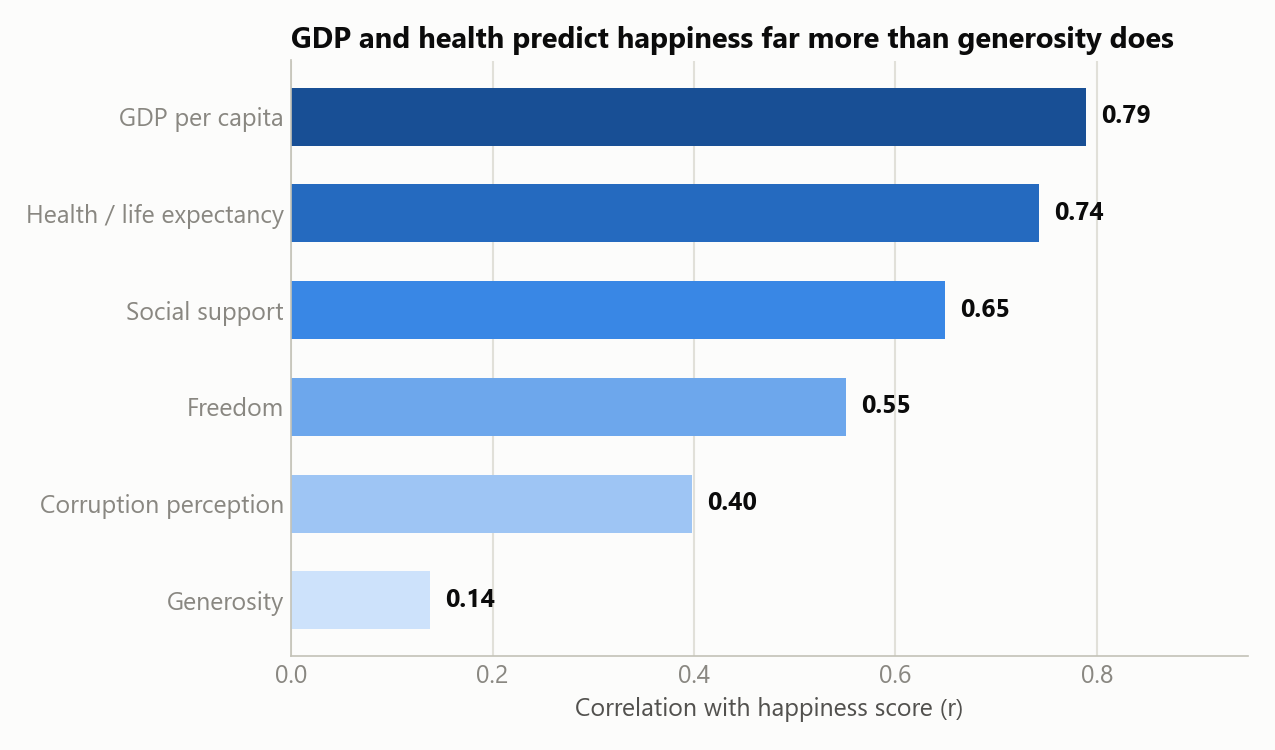

In [2]:
corr = pd.read_csv(os.path.join(SUMMARY_DIR, "factor_correlations.csv"), index_col=0)
corr = corr.reindex(["gdp_per_capita","health_life_expectancy","social_support","freedom","corruption_perception","generosity"])
labels = [label_map[i] for i in corr.index]

fig, ax = plt.subplots(figsize=(8.5, 5))
y = range(len(labels))
ax.barh(y, corr["correlation"], color=list(reversed(SEQ6)), height=0.6)
for i, v in enumerate(corr["correlation"]):
    ax.text(v + 0.015, i, f"{v:.2f}", va="center", fontsize=12, color=INK_PRIMARY, fontweight="bold")
ax.set_yticks(list(y)); ax.set_yticklabels(labels); ax.invert_yaxis()
ax.set_xlim(0, 0.95); ax.set_xlabel("Correlation with happiness score (r)")
clean_axes(ax)
ax.xaxis.grid(True, color=GRID, linewidth=1)
ax.set_title("GDP and health predict happiness far more than generosity does", fontsize=14,
              color=INK_PRIMARY, fontweight="bold", loc="left")
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, "01_factor_correlations.png"), dpi=150)
plt.show()

## 2. GDP per capita vs. happiness

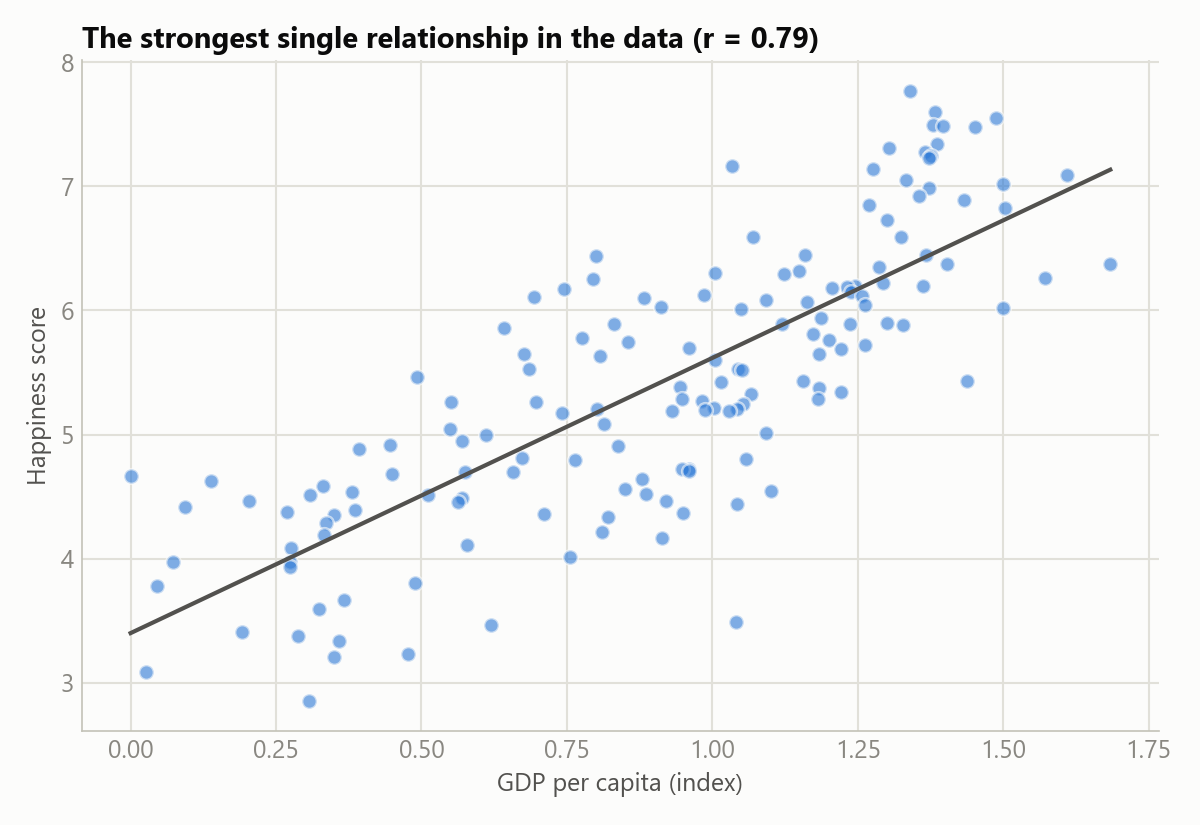

In [3]:
panel = pd.read_parquet(os.path.join(PROC_DIR, "happiness_panel.parquet"))
latest = panel[panel["year"] == 2019].dropna(subset=["gdp_per_capita", "happiness_score"])

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(latest["gdp_per_capita"], latest["happiness_score"], s=50, color=BLUE, alpha=0.6,
           edgecolor=SURFACE, linewidth=1.2, zorder=3)
z = np.polyfit(latest["gdp_per_capita"], latest["happiness_score"], 1)
xs = np.linspace(latest["gdp_per_capita"].min(), latest["gdp_per_capita"].max(), 50)
ax.plot(xs, np.polyval(z, xs), color=INK_SECONDARY, linewidth=2, zorder=4)
clean_axes(ax)
ax.xaxis.grid(True, color=GRID, linewidth=1); ax.yaxis.grid(True, color=GRID, linewidth=1)
ax.set_xlabel("GDP per capita (index)"); ax.set_ylabel("Happiness score")
ax.set_title("The strongest single relationship in the data (r = 0.79)", fontsize=14,
              color=INK_PRIMARY, fontweight="bold", loc="left")
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, "02_gdp_vs_happiness.png"), dpi=150)
plt.show()

## 3. Regional averages (2019)

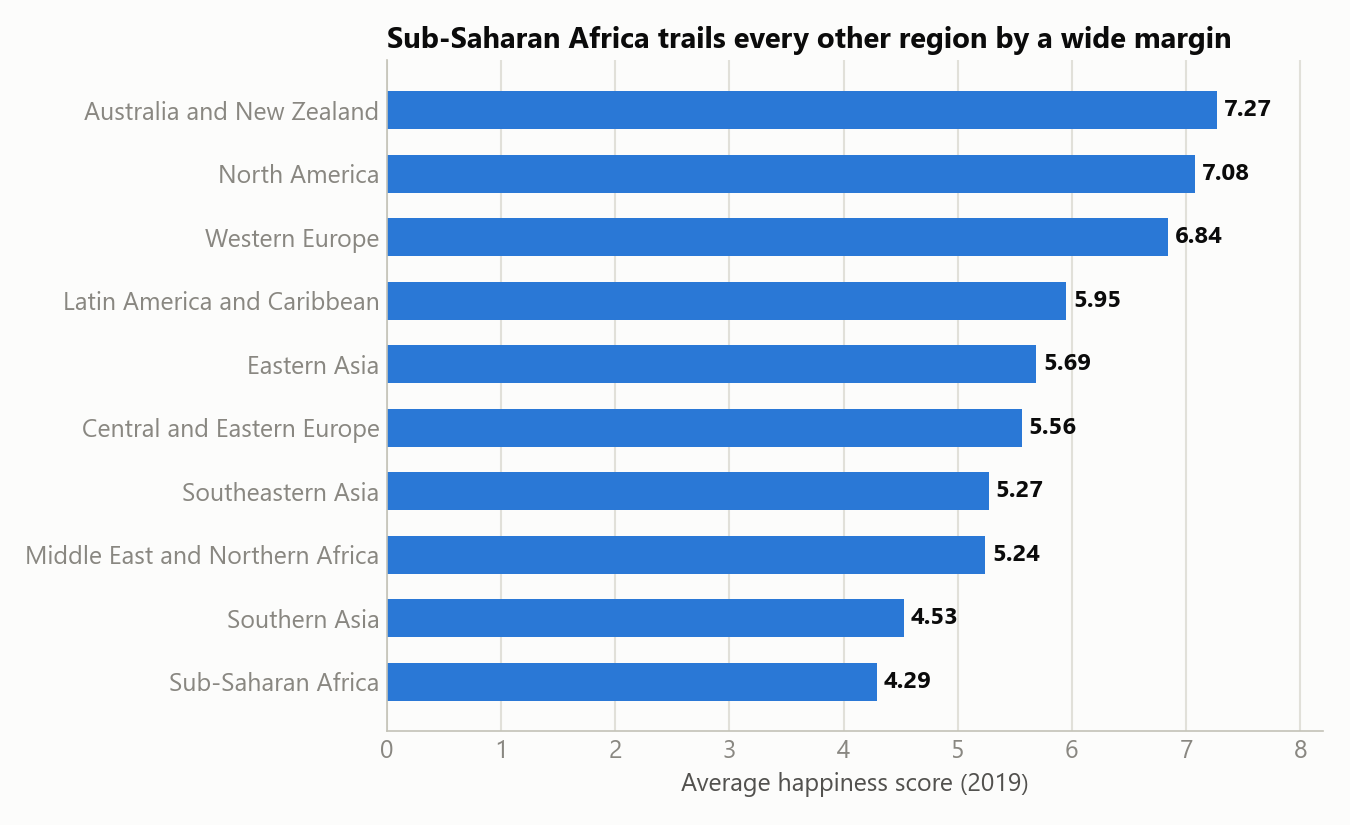

In [4]:
reg = pd.read_csv(os.path.join(SUMMARY_DIR, "regional_averages_2019.csv"), index_col=0).sort_values("mean")

fig, ax = plt.subplots(figsize=(9, 5.5))
y = range(len(reg))
ax.barh(y, reg["mean"], color=BLUE, height=0.6)
for i, v in enumerate(reg["mean"]):
    ax.text(v + 0.06, i, f"{v:.2f}", va="center", fontsize=11.5, color=INK_PRIMARY, fontweight="bold")
ax.set_yticks(list(y)); ax.set_yticklabels(reg.index)
ax.set_xlim(0, 8.2); ax.set_xlabel("Average happiness score (2019)")
clean_axes(ax)
ax.xaxis.grid(True, color=GRID, linewidth=1)
ax.set_title("Sub-Saharan Africa trails every other region by a wide margin", fontsize=14,
              color=INK_PRIMARY, fontweight="bold", loc="left")
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, "03_regional_averages.png"), dpi=150)
plt.show()

## 4. Global trend, 2015-2019

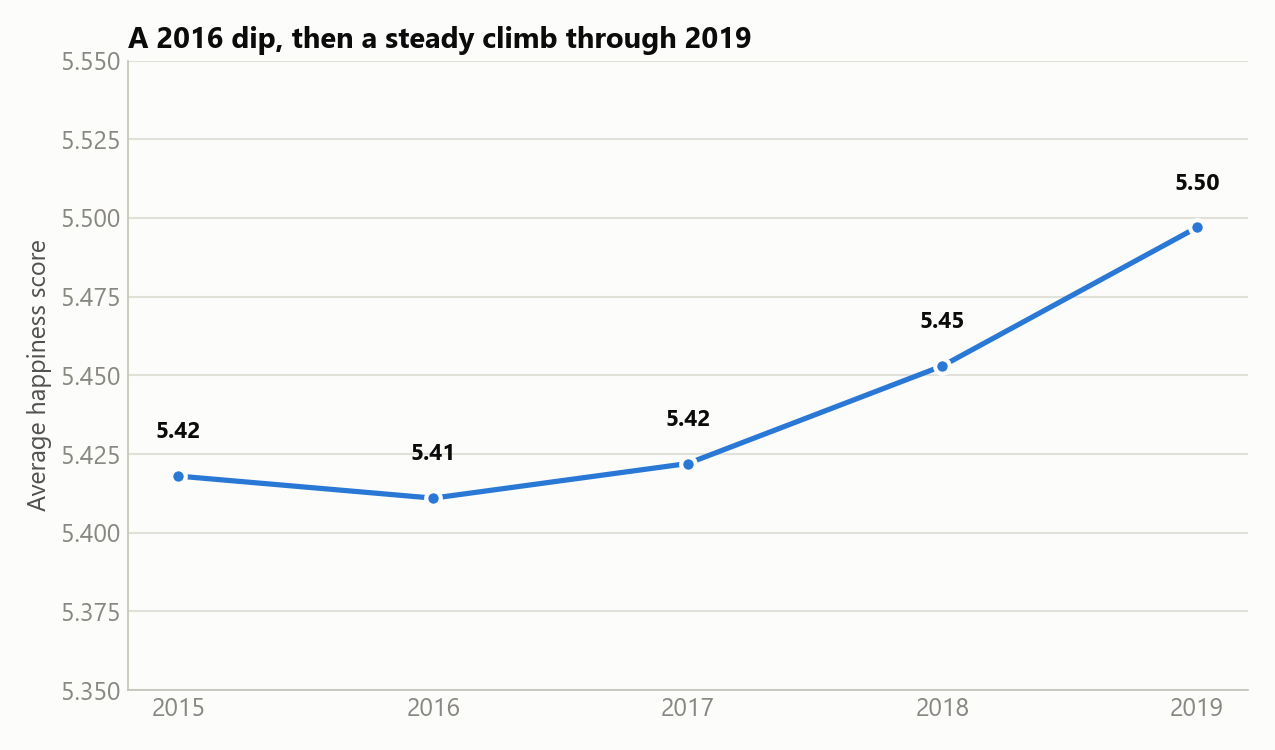

In [5]:
trend = pd.read_csv(os.path.join(SUMMARY_DIR, "global_trend.csv"), index_col=0)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(trend.index, trend["mean_happiness_score"], color=BLUE, linewidth=2.5, marker="o",
        markersize=7, markerfacecolor=BLUE, markeredgecolor=SURFACE, markeredgewidth=2)
for x, v in zip(trend.index, trend["mean_happiness_score"]):
    ax.text(x, v + 0.012, f"{v:.2f}", ha="center", fontsize=11, color=INK_PRIMARY, fontweight="bold")
ax.set_xticks(trend.index)
clean_axes(ax)
ax.yaxis.grid(True, color=GRID, linewidth=1)
ax.set_ylim(5.35, 5.55)
ax.set_ylabel("Average happiness score")
ax.set_title("A 2016 dip, then a steady climb through 2019", fontsize=14,
              color=INK_PRIMARY, fontweight="bold", loc="left")
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, "04_global_trend.png"), dpi=150)
plt.show()

## 5. What separates the happiest countries from the least happy

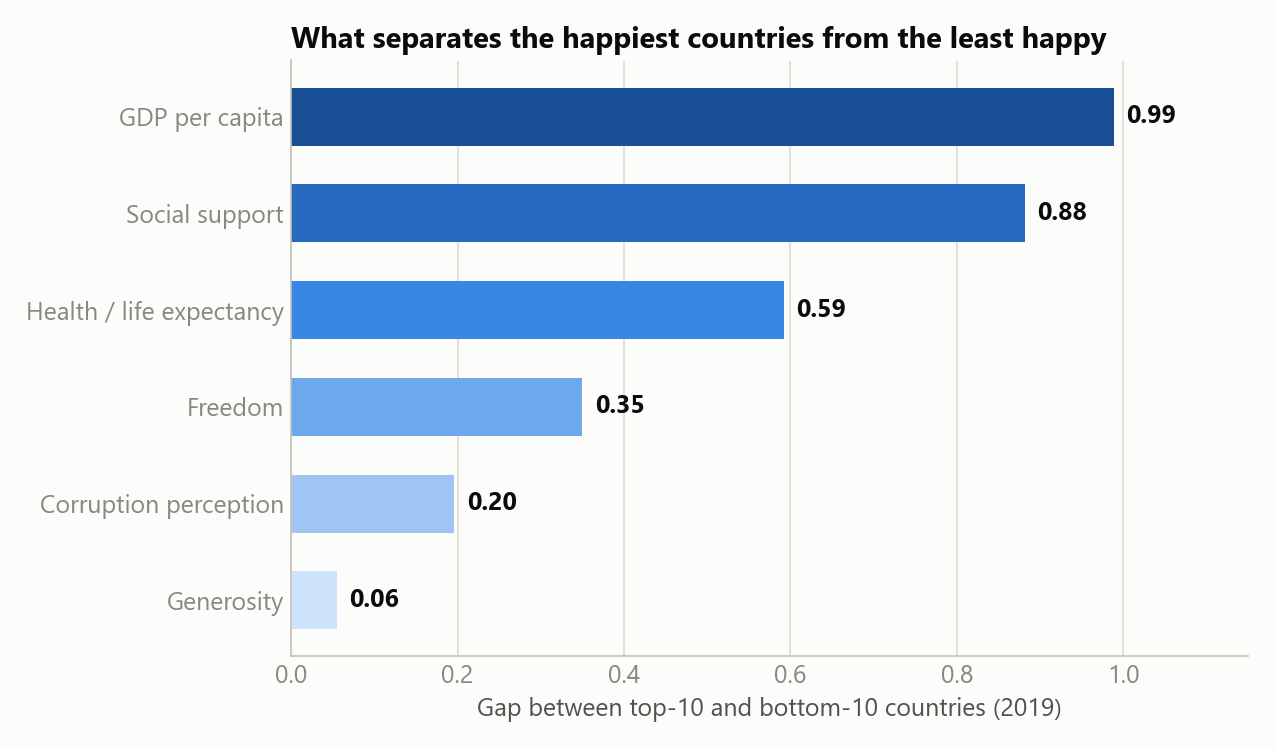

In [6]:
gap = pd.read_csv(os.path.join(SUMMARY_DIR, "top_vs_bottom_factors.csv"), index_col=0)
gap = gap.reindex(["gdp_per_capita","social_support","health_life_expectancy","freedom","corruption_perception","generosity"])
labels5 = [label_map[i] for i in gap.index]

fig, ax = plt.subplots(figsize=(8.5, 5))
y = range(len(labels5))
ax.barh(y, gap["gap"], color=list(reversed(SEQ6)), height=0.6)
for i, v in enumerate(gap["gap"]):
    ax.text(v + 0.015, i, f"{v:.2f}", va="center", fontsize=12, color=INK_PRIMARY, fontweight="bold")
ax.set_yticks(list(y)); ax.set_yticklabels(labels5); ax.invert_yaxis()
ax.set_xlim(0, 1.15); ax.set_xlabel("Gap between top-10 and bottom-10 countries (2019)")
clean_axes(ax)
ax.xaxis.grid(True, color=GRID, linewidth=1)
ax.set_title("What separates the happiest countries from the least happy", fontsize=14,
              color=INK_PRIMARY, fontweight="bold", loc="left")
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, "05_top_vs_bottom_gap.png"), dpi=150)
plt.show()

## Summary

Every chart tells the same story from a different angle: **economic security and social
support — not generosity or even freedom — are what most separate happier countries from less
happy ones.** See [`docs/05_share.md`](../docs/05_share.md) for the full write-up.